Initial Clustering on 2D Projection:
  KMeans Silhouette Score: 0.3981
  GMM Silhouette Score: 0.4100
  GMM AIC: 5350.5675
  GMM BIC: 5401.5629
Initial Clustering on 2D Projection:
  KMeans Silhouette Score: 0.5152
  GMM Silhouette Score: 0.4638
  GMM AIC: 13508.1217
  GMM BIC: 13568.5237


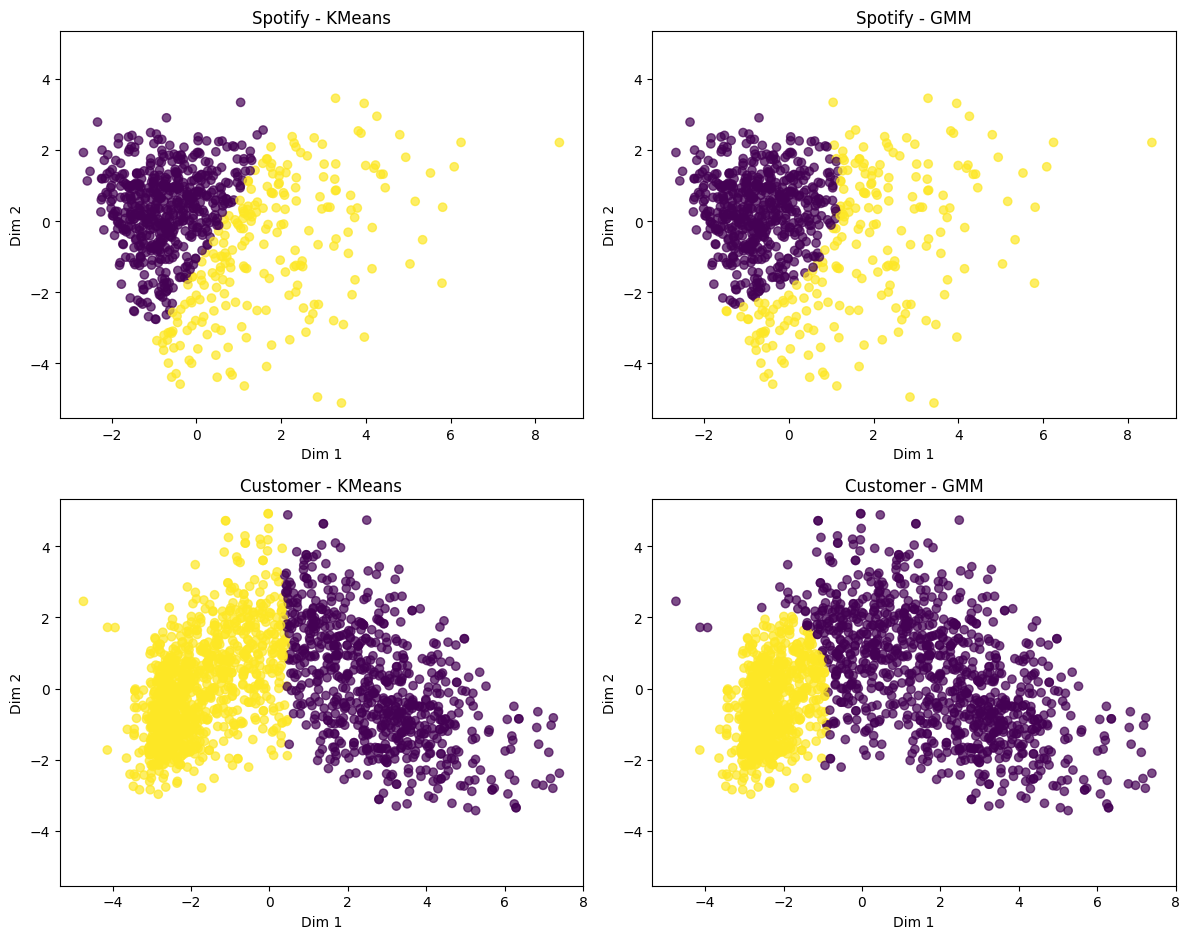

Spotify - PCA Cumulative Explained Variance (first 10 comps): [0.16328576 0.31156702 0.39777616 0.47512555 0.5464988  0.6149682
 0.68011609 0.74378184 0.80210294 0.85770238]
Customer - PCA Cumulative Explained Variance (first 10 comps): [0.19119816 0.25790144 0.31211534 0.36086774 0.40592987 0.44846871
 0.48737603 0.52304983 0.55700583 0.58974752]
Spotify - ICA Kurtosis: [ 1.13303433 14.99418992  7.50914906  2.53432601  2.34785807  2.36871874
  8.09947153  1.89756698  3.25291517  9.54929082]
Customer - ICA Kurtosis: [13.30667935  3.38892495  1.88345156  1.50523702 11.51460655  3.82939713
  1.4471717   1.35223501 21.73282137  1.65455339]
Spotify - RP Reconstruction Error: 0.3604
Customer - RP Reconstruction Error: 0.6787


C:\Users\louis\AppData\Local\Temp\ipykernel_10512\4070532382.py:182: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_10512\4070532382.py:182: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_10512\4070532382.py:202: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_10512\4070532382.py:202: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_10512\4070532382.py:208: UserWarning: No data for colormapping p

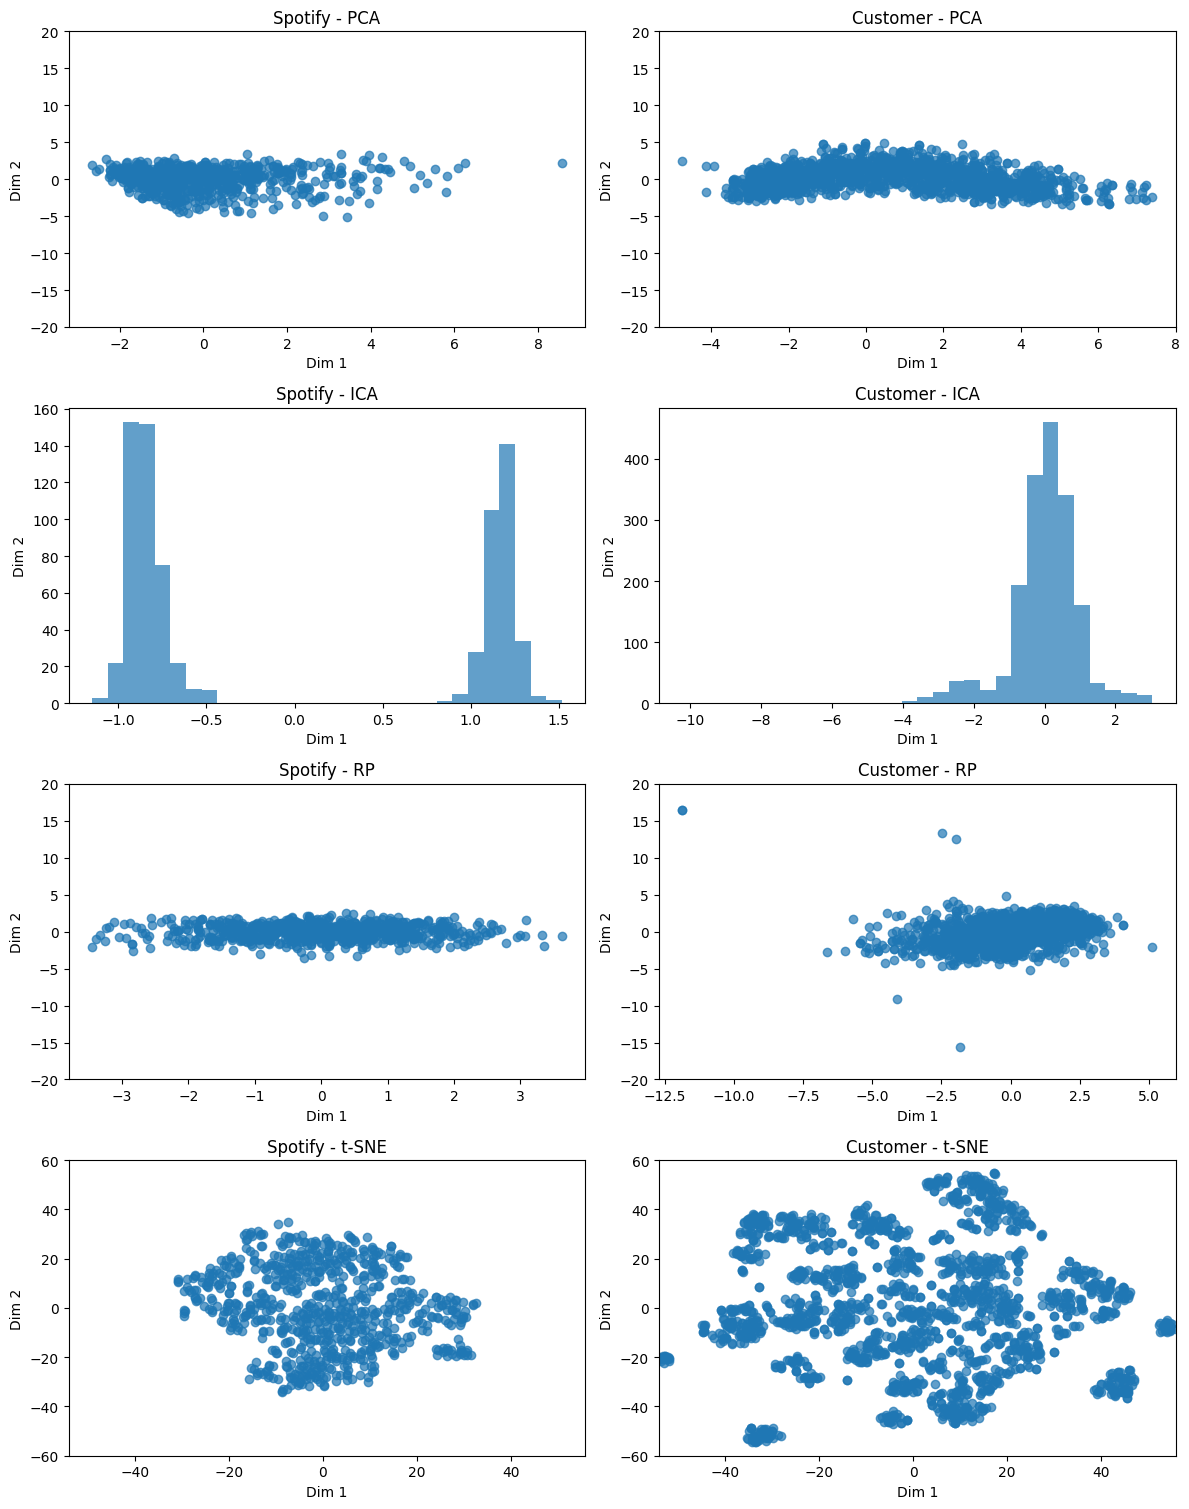

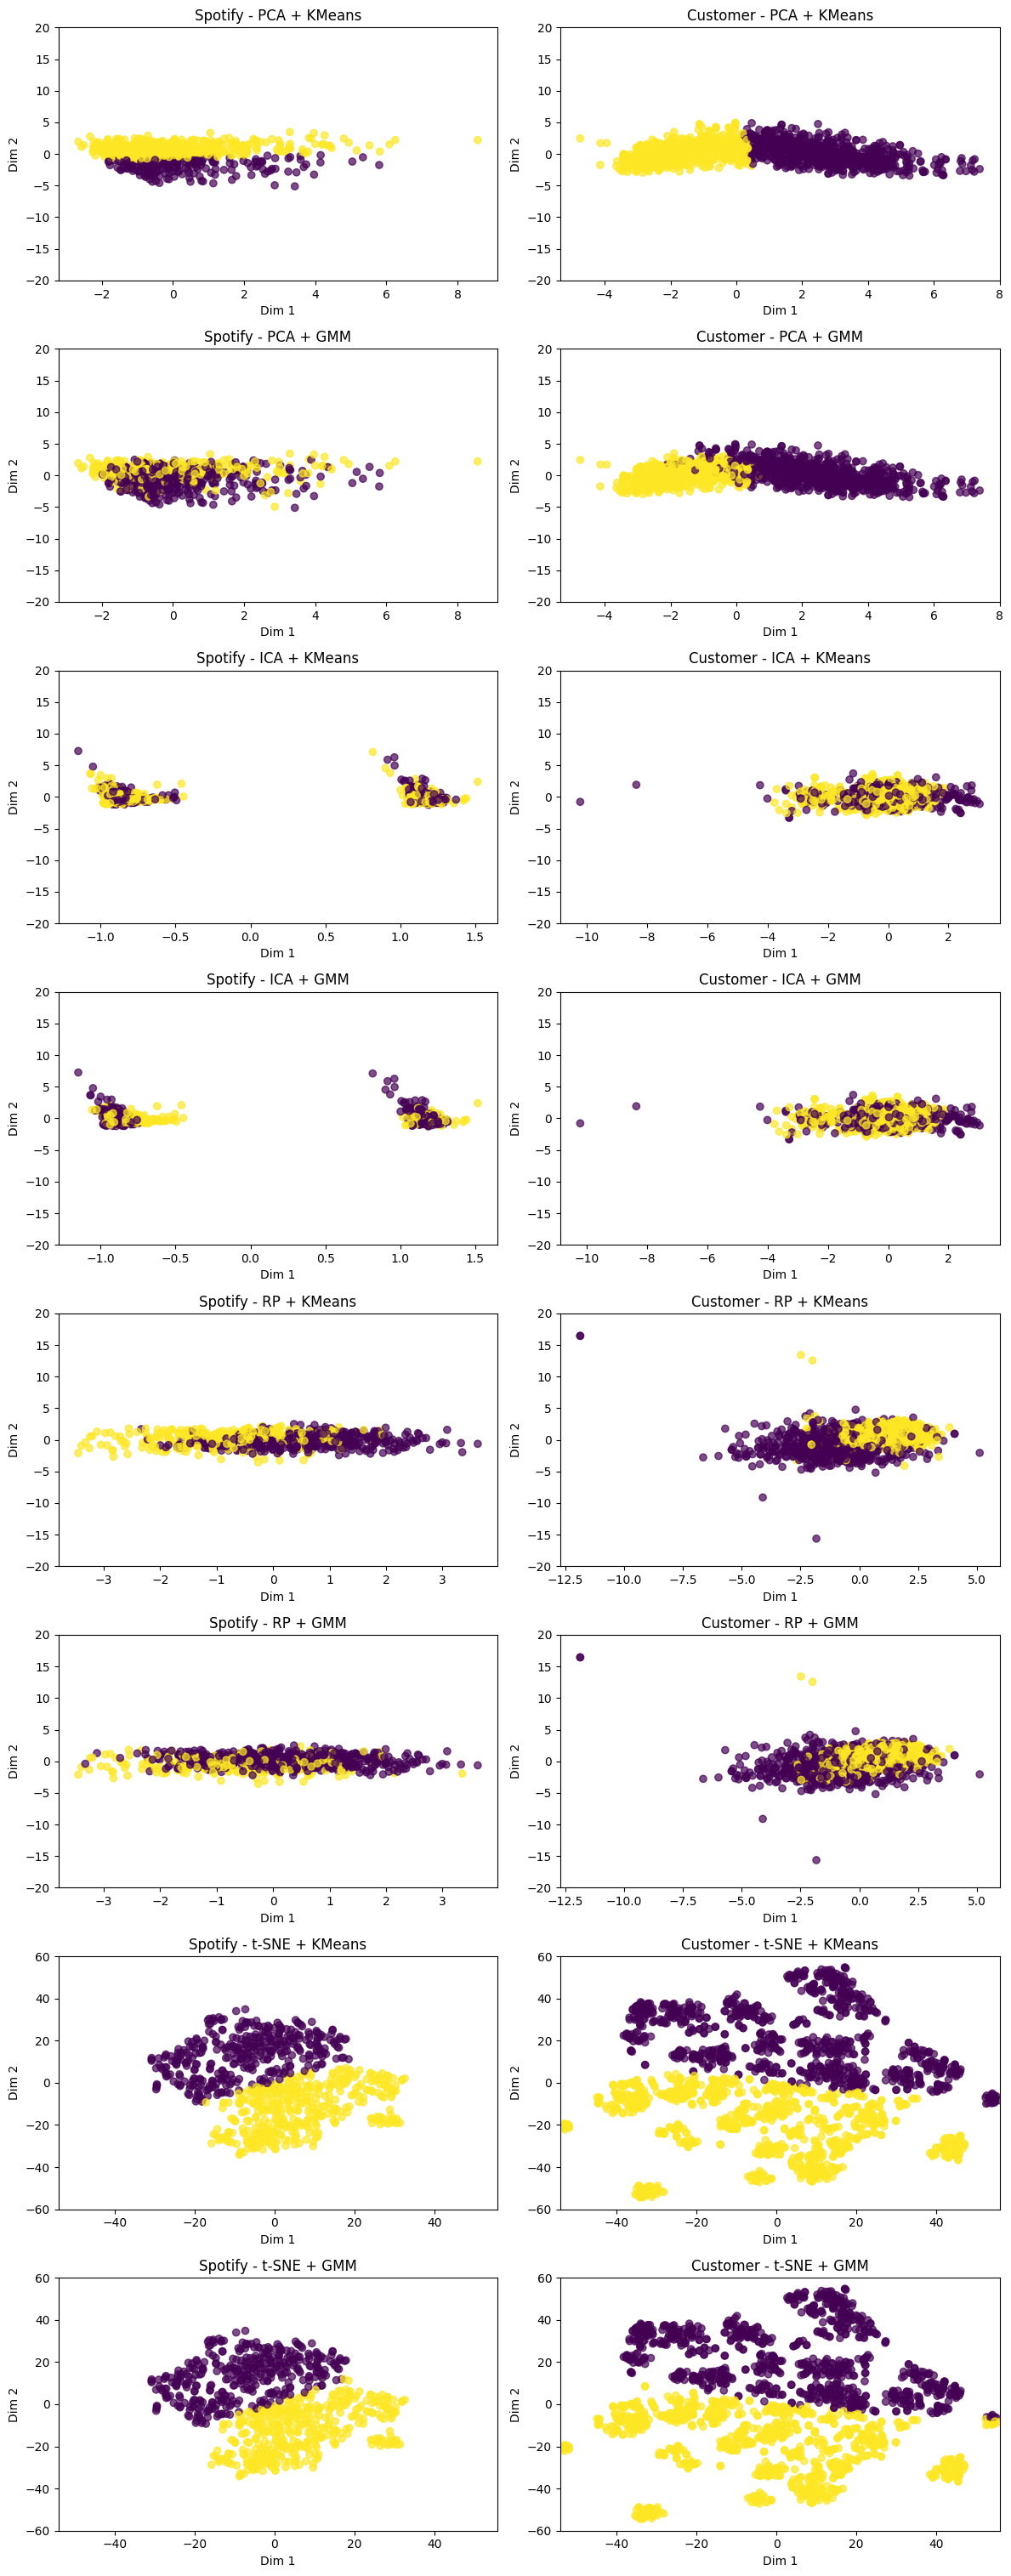


Training NN for configuration: DR with PCA
Epoch 1/50, Loss: 0.5405
Epoch 2/50, Loss: 0.3777
Epoch 3/50, Loss: 0.3284
Epoch 4/50, Loss: 0.3167
Epoch 5/50, Loss: 0.3202
Epoch 6/50, Loss: 0.3154
Epoch 7/50, Loss: 0.2957
Epoch 8/50, Loss: 0.2932
Epoch 9/50, Loss: 0.3042
Epoch 10/50, Loss: 0.2913
Epoch 11/50, Loss: 0.2837
Epoch 12/50, Loss: 0.2809
Epoch 13/50, Loss: 0.2723
Epoch 14/50, Loss: 0.2908
Epoch 15/50, Loss: 0.2832
Epoch 16/50, Loss: 0.2820
Epoch 17/50, Loss: 0.2812
Epoch 18/50, Loss: 0.2658
Epoch 19/50, Loss: 0.2678
Epoch 20/50, Loss: 0.2562
Epoch 21/50, Loss: 0.2653
Epoch 22/50, Loss: 0.2531
Epoch 23/50, Loss: 0.2569
Epoch 24/50, Loss: 0.2631
Epoch 25/50, Loss: 0.2503
Epoch 26/50, Loss: 0.2421
Epoch 27/50, Loss: 0.2489
Epoch 28/50, Loss: 0.2614
Epoch 29/50, Loss: 0.2458
Epoch 30/50, Loss: 0.2549
Epoch 31/50, Loss: 0.2449
Epoch 32/50, Loss: 0.2563
Epoch 33/50, Loss: 0.2427
Epoch 34/50, Loss: 0.2483
Epoch 35/50, Loss: 0.2318
Epoch 36/50, Loss: 0.2491
Epoch 37/50, Loss: 0.2441
Epo

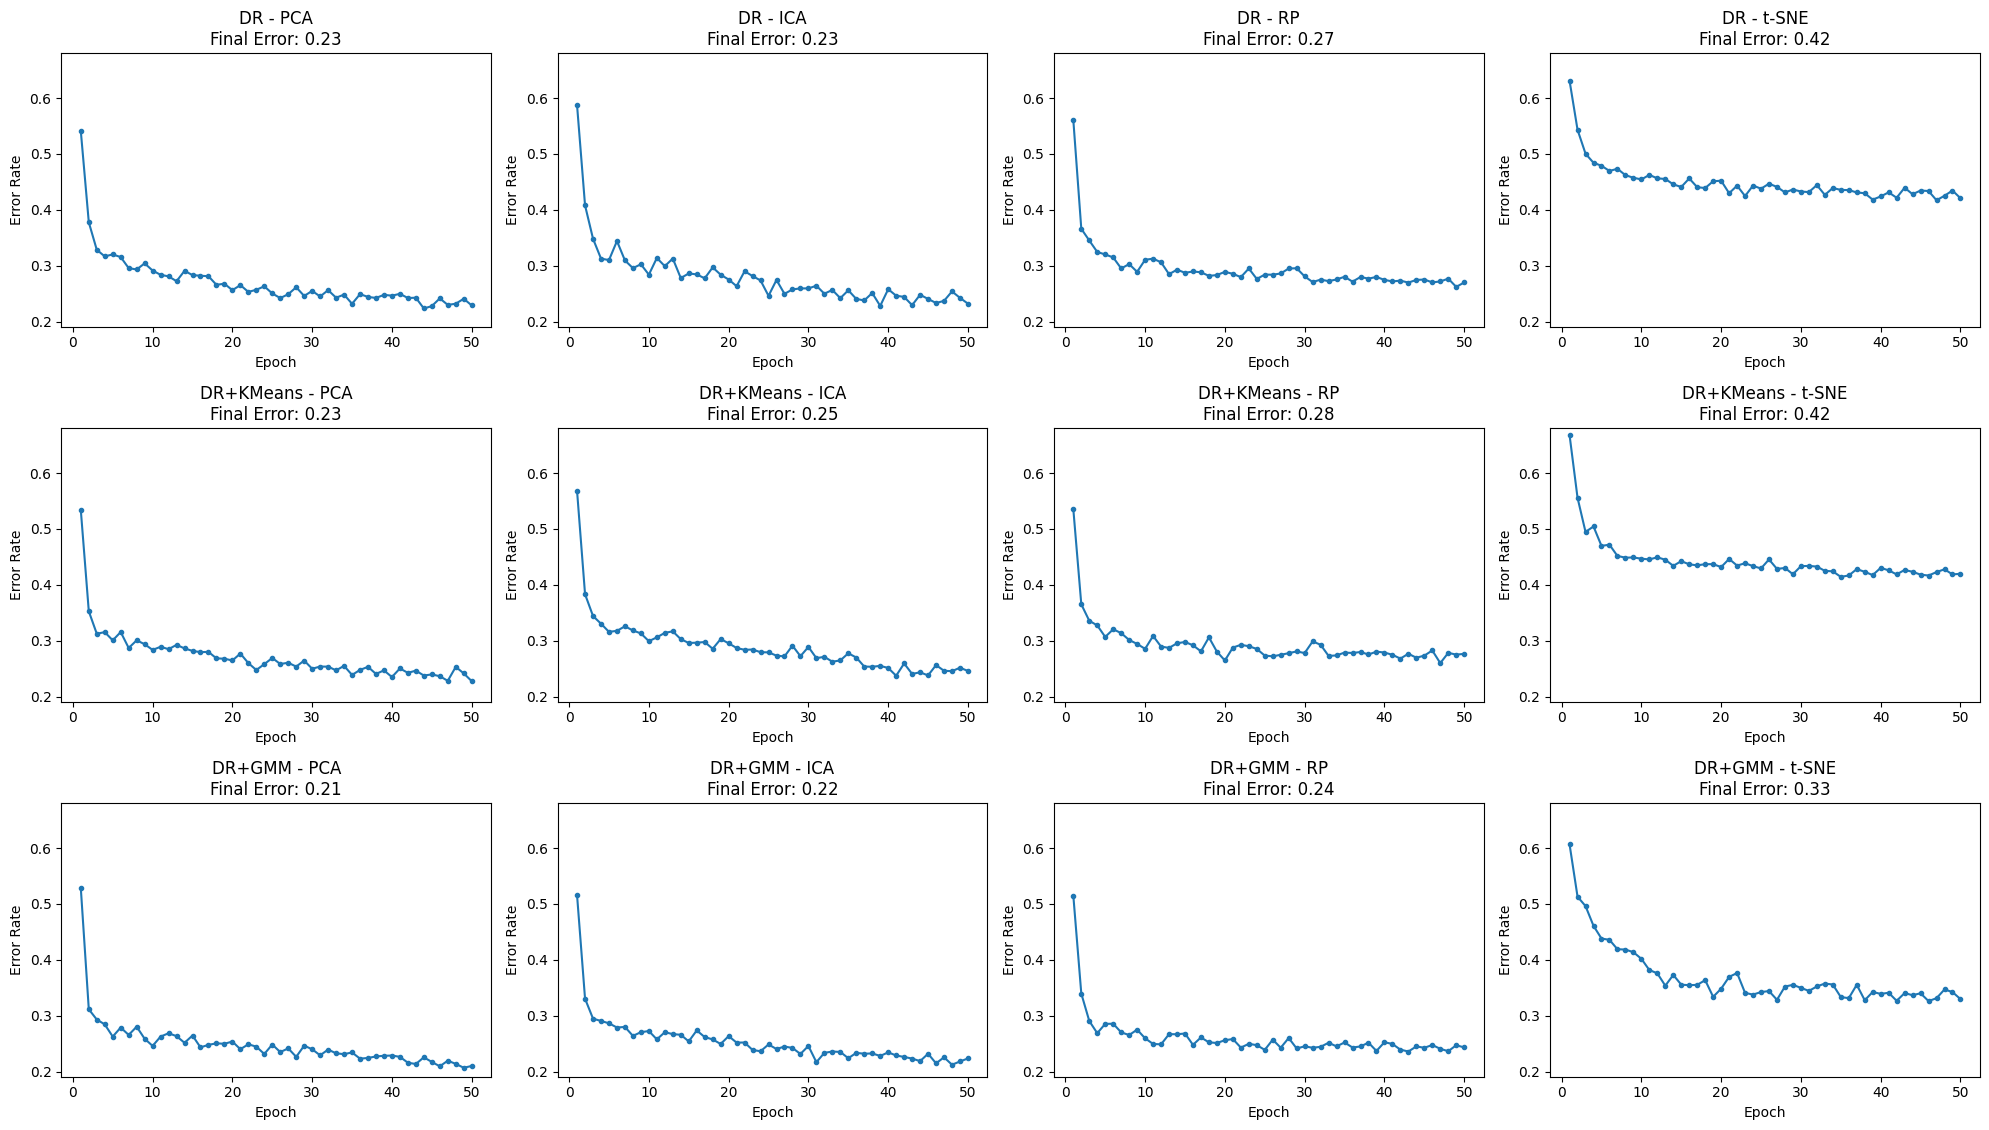

all steps done


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import scipy.stats as stats



def set_common_ylims(ax_list):
    """
    Set a common y-axis range for a group of subplots.
    """
    ymins = []
    ymaxs = []
    for ax in ax_list:
        y_min, y_max = ax.get_ylim()
        ymins.append(y_min)
        ymaxs.append(y_max)
    common_ymin = min(ymins)
    common_ymax = max(ymaxs)
    for ax in ax_list:
        ax.set_ylim(common_ymin, common_ymax)

def unify_xy_lims(ax_list):
    """
    Set a common x-axis and y-axis range for a group of subplots.
    """
    all_xmins, all_xmaxs = [], []
    all_ymins, all_ymaxs = [], []
    for ax in ax_list:
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        all_xmins.append(x_min)
        all_xmaxs.append(x_max)
        all_ymins.append(y_min)
        all_ymaxs.append(y_max)
    common_xmin = min(all_xmins)
    common_xmax = max(all_xmaxs)
    common_ymin = min(all_ymins)
    common_ymax = max(all_ymaxs)
    for ax in ax_list:
        ax.set_xlim(common_xmin, common_xmax)
        ax.set_ylim(common_ymin, common_ymax)

def plot_scatter(ax, X, labels=None, title='Scatter Plot', xlabel='Dim 1', ylabel='Dim 2'):
    """
    Plot a scatter plot on the given ax.
    """
    if X.shape[1] < 2:
        ax.text(0.5, 0.5, "Insufficient dimensions", horizontalalignment='center')
        return
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

def plot_histogram(ax, data, bins=30, title='Histogram', xlabel='Value', ylabel='Frequency'):
    """
     Plot a histogram on the given ax.
    """
    ax.hist(data, bins=bins, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


# 1. Data Loading and Preprocessing

def split_features_labels_spotify(df):
    """Spotify dataset: target column is 'popularity'"""
    X = df.drop(columns=['popularity'])
    y = df['popularity']
    return X, y

def split_features_labels_customer(df):
    """Customer dataset: target column is 'Response'"""
    X = df.drop(columns=['Response'])
    y = df['Response']
    return X, y

spotify_train = pd.read_csv('train_processed.csv')
spotify_test  = pd.read_csv('test_processed.csv')
customer_train = pd.read_csv('customer_train.csv')
customer_test  = pd.read_csv('customer_test.csv')

X_spotify_train_raw, y_spotify_train_raw = split_features_labels_spotify(spotify_train)
X_spotify_test_raw,  y_spotify_test_raw  = split_features_labels_spotify(spotify_test)
X_customer_train_raw, y_customer_train_raw = split_features_labels_customer(customer_train)
X_customer_test_raw,  y_customer_test_raw  = split_features_labels_customer(customer_test)

scaler_spotify = StandardScaler()
X_spotify_train_scaled = scaler_spotify.fit_transform(X_spotify_train_raw)
X_spotify_test_scaled  = scaler_spotify.transform(X_spotify_test_raw)

scaler_customer = StandardScaler()
X_customer_train_scaled = scaler_customer.fit_transform(X_customer_train_raw)
X_customer_test_scaled  = scaler_customer.transform(X_customer_test_raw)

le_spotify = LabelEncoder()
y_spotify_train_enc = le_spotify.fit_transform(y_spotify_train_raw)
y_spotify_test_enc  = le_spotify.transform(y_spotify_test_raw)

le_customer = LabelEncoder()
y_customer_train_enc = le_customer.fit_transform(y_customer_train_raw)
y_customer_test_enc  = le_customer.transform(y_customer_test_raw)

# 2. Step 1 – Initial Clustering

def initial_clustering(X_scaled, n_clusters):
    # Use PCA to project data into 2D for visualization
    pca_vis = PCA(n_components=2, random_state=42)
    X_vis = pca_vis.fit_transform(X_scaled)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels_km = kmeans.fit_predict(X_vis)
    
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    labels_gmm = gmm.fit_predict(X_vis)
    
    # Compute clustering metrics on 2D data
    sil_km = silhouette_score(X_vis, labels_km)
    sil_gmm = silhouette_score(X_vis, labels_gmm)
    print("Initial Clustering on 2D Projection:")
    print("  KMeans Silhouette Score: {:.4f}".format(sil_km))
    print("  GMM Silhouette Score: {:.4f}".format(sil_gmm))
    print("  GMM AIC: {:.4f}".format(gmm.aic(X_vis)))
    print("  GMM BIC: {:.4f}".format(gmm.bic(X_vis)))
    
    return labels_km, labels_gmm, X_vis

n_clusters_spotify = len(np.unique(y_spotify_train_enc))
n_clusters_customer = len(np.unique(y_customer_train_enc))

km_labels_spotify, gmm_labels_spotify, X_spotify_vis = initial_clustering(X_spotify_train_scaled, n_clusters_spotify)
km_labels_customer, gmm_labels_customer, X_customer_vis = initial_clustering(X_customer_train_scaled, n_clusters_customer)

fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
# fig1.suptitle("Step 1: Clustering Result", fontsize=16)

plot_scatter(axes1[0, 0], X_spotify_vis, labels=km_labels_spotify, title="Spotify - KMeans")
plot_scatter(axes1[0, 1], X_spotify_vis, labels=gmm_labels_spotify, title="Spotify - GMM")
plot_scatter(axes1[1, 0], X_customer_vis, labels=km_labels_customer, title="Customer - KMeans")
plot_scatter(axes1[1, 1], X_customer_vis, labels=gmm_labels_customer, title="Customer - GMM")

set_common_ylims(axes1.flatten())
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig1.savefig('step1_clustering_result.png')

# 3. Step 2 – Dimension Reduction Experiment
#    - PCA & RP enforce y-axis range [-20,20]
#    - ICA / t-SNE do not enforce any range
#    - Ensure consistent coordinate range for t-SNE (Spotify, Customer)

dr_methods = ['PCA', 'ICA', 'RP', 't-SNE']
fig2, axes2 = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
# fig2.suptitle("Step 2: Dimension Reduction", fontsize=16)

tsne_axes = []
tsne_data_list = []

for i, method in enumerate(dr_methods):
    for j, (dataset_name, X_train_scaled) in enumerate([("Spotify", X_spotify_train_scaled),
                                                         ("Customer", X_customer_train_scaled)]):
        ax = axes2[i, j]
        if method == 'PCA':
            dr = PCA(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
            # print cumulative explained variance
            cum_exp = np.cumsum(dr.explained_variance_ratio_)
            print(f"{dataset_name} - PCA Cumulative Explained Variance (first 10 comps):", cum_exp)
            ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
            ax.set_title(f"{dataset_name} - PCA")
            ax.set_ylim(-20, 20)  # force [-20,20]
        elif method == 'ICA':
            dr = FastICA(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
            # print ICA Kurtosis
            kurt_vals = stats.kurtosis(X_dr, fisher=False)
            print(f"{dataset_name} - ICA Kurtosis:", kurt_vals)
            ax.hist(X_dr[:, 0], bins=30, alpha=0.7)
            ax.set_title(f"{dataset_name} - ICA")
        elif method == 'RP':
            dr = GaussianRandomProjection(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
            R = dr.components_
            # do reconstruction error calculation
            R_pinv = np.linalg.pinv(R.T)  # (n_features, 10)
            X_rp_recon = X_dr.dot(R_pinv)  # (n_samples, 10) dot (10, n_features) -> (n_samples, n_features)
            recon_error = np.mean((X_train_scaled - X_rp_recon) ** 2)
            print(f"{dataset_name} - RP Reconstruction Error: {recon_error:.4f}")
            ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
            ax.set_title(f"{dataset_name} - RP")
            ax.set_ylim(-20, 20)
        elif method == 't-SNE':
            tsne = TSNE(n_components=2, random_state=42, perplexity=30)
            X_dr = tsne.fit_transform(X_train_scaled)
            ax.scatter(X_dr[:, 0], X_dr[:, 1], alpha=0.7, cmap='viridis')
            ax.set_title(f"{dataset_name} - t-SNE")
            tsne_axes.append(ax)
            tsne_data_list.append(X_dr)

        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

# unify x-y limits for all t-SNE plots
if len(tsne_axes) == 2 and len(tsne_data_list) == 2:
    all_tsne_data = np.concatenate(tsne_data_list, axis=0)
    min_x, max_x = all_tsne_data[:,0].min(), all_tsne_data[:,0].max()
    min_y, max_y = all_tsne_data[:,1].min(), all_tsne_data[:,1].max()
    for ax in tsne_axes:
        ax.set_xlim(min_x, max_x)
        ax.set_ylim(-60, 60)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig2.savefig('step2_dimension_reduction.png')

# 4. Step 3 – clustering on data with dimension reduction
#    - PCA / ICA / RP
#    - t-SNE not enforced y-axis

fig3, axes3 = plt.subplots(nrows=8, ncols=2, figsize=(12, 32))
# fig3.suptitle("Step 3: Clustering on Data with Dimension Reduction", fontsize=16)

tsne_axes_step3 = []
tsne_data_step3 = []

for j, (dataset_name, X_train_scaled, n_clusters) in enumerate([
    ("Spotify", X_spotify_train_scaled, n_clusters_spotify),
    ("Customer", X_customer_train_scaled, n_clusters_customer)
]):
    for i, method in enumerate(dr_methods):
        if method == 'PCA':
            dr = PCA(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
        elif method == 'ICA':
            dr = FastICA(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
        elif method == 'RP':
            dr = GaussianRandomProjection(n_components=10, random_state=42)
            X_dr = dr.fit_transform(X_train_scaled)
        elif method == 't-SNE':
            tsne = TSNE(n_components=2, random_state=42, perplexity=30)
            X_dr = tsne.fit_transform(X_train_scaled)

        row_idx_km = i * 2
        row_idx_gmm = i * 2 + 1

        # KMeans
        km = KMeans(n_clusters=n_clusters, random_state=42)
        labels_km = km.fit_predict(X_dr)
        ax_km = axes3[row_idx_km, j]
        if X_dr.shape[1] >= 2:
            ax_km.scatter(X_dr[:, 0], X_dr[:, 1], c=labels_km, cmap='viridis', alpha=0.7)
        ax_km.set_title(f"{dataset_name} - {method} + KMeans")
        ax_km.set_xlabel("Dim 1")
        ax_km.set_ylabel("Dim 2")

        # GMM
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        labels_gmm = gmm.fit_predict(X_dr)
        ax_gmm = axes3[row_idx_gmm, j]
        if X_dr.shape[1] >= 2:
            ax_gmm.scatter(X_dr[:, 0], X_dr[:, 1], c=labels_gmm, cmap='viridis', alpha=0.7)
        ax_gmm.set_title(f"{dataset_name} - {method} + GMM")
        ax_gmm.set_xlabel("Dim 1")
        ax_gmm.set_ylabel("Dim 2")

        if method in ['PCA', 'ICA', 'RP']:
            ax_km.set_ylim(-20, 20)
            ax_gmm.set_ylim(-20, 20)
        if method == 't-SNE':
            tsne_axes_step3.extend([ax_km, ax_gmm])
            tsne_data_step3.append(X_dr)

if len(tsne_axes_step3) > 0 and len(tsne_data_step3) > 0:
    all_t_data = np.concatenate(tsne_data_step3, axis=0)
    min_x, max_x = all_t_data[:,0].min(), all_t_data[:,0].max()
    min_y, max_y = all_t_data[:,1].min(), all_t_data[:,1].max()
    for ax in tsne_axes_step3:
        ax.set_xlim(min_x, max_x)
        ax.set_ylim(-60, 60)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig3.savefig('step3_clustering_after_dr.png')

# 5. Step 4 & 5 – Train Neural Network on Reduced Data
class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.tanh1 = nn.Tanh()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 64)
        self.tanh2 = nn.Tanh()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 64)
        self.tanh3 = nn.Tanh()
        self.fc4 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.tanh1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.tanh2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.tanh3(x)
        x = self.fc4(x)
        return x

def create_data_loaders(X_train, y_train, X_test, y_test, batch_size=32):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test, dtype=torch.long)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_model(model, train_loader, test_loader, num_epochs=50, device='cpu', convergence_threshold=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    loss_curve = []
    convergence_epoch = None
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for data, labels in train_loader:
            data = data.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * data.size(0)
        epoch_loss /= len(train_loader.dataset)
        loss_curve.append(epoch_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")
        # check for convergence
        if epoch >= 5:
            recent_diff = np.abs(np.diff(loss_curve[-5:]))
            if np.max(recent_diff) < convergence_threshold and convergence_epoch is None:
                convergence_epoch = epoch - 4  # start of the 5-epoch window
    if convergence_epoch is not None:
        print(f"Model converged at epoch: {convergence_epoch}")
    else:
        print("Model did not converge within the specified epochs.")
    # test error rate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            labels = labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    error_rate = 1 - accuracy
    print(f"Final Test Accuracy: {accuracy:.4f}, Error Rate: {error_rate:.4f}")
    return loss_curve

dr_methods = ['PCA', 'ICA', 'RP', 't-SNE']

# construct features for NN training
nn_features_DR = {}
for method in dr_methods:
    if method == 'PCA':
        dr = PCA(n_components=10, random_state=42)
        X_train_dr = dr.fit_transform(X_spotify_train_scaled)
        X_test_dr  = dr.transform(X_spotify_test_scaled)
    elif method == 'ICA':
        dr = FastICA(n_components=10, random_state=42)
        X_train_dr = dr.fit_transform(X_spotify_train_scaled)
        X_test_dr  = dr.transform(X_spotify_test_scaled)
    elif method == 'RP':
        dr = GaussianRandomProjection(n_components=10, random_state=42)
        X_train_dr = dr.fit_transform(X_spotify_train_scaled)
        X_test_dr  = dr.transform(X_spotify_test_scaled)
    elif method == 't-SNE':
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_train_dr = tsne.fit_transform(X_spotify_train_scaled)
        tsne_test = TSNE(n_components=2, random_state=42, perplexity=30)
        X_test_dr = tsne_test.fit_transform(X_spotify_test_scaled)
    nn_features_DR[method] = (X_train_dr, X_test_dr)

kmeans_model = KMeans(n_clusters=n_clusters_spotify, random_state=42).fit(X_spotify_train_scaled)
gmm_model = GaussianMixture(n_components=n_clusters_spotify, random_state=42).fit(X_spotify_train_scaled)
km_train_labels = kmeans_model.predict(X_spotify_train_scaled)
km_test_labels  = kmeans_model.predict(X_spotify_test_scaled)
gmm_train_labels = gmm_model.predict(X_spotify_train_scaled)
gmm_test_labels  = gmm_model.predict(X_spotify_test_scaled)

encoder_km = OneHotEncoder(sparse_output=False)
km_train_oh = encoder_km.fit_transform(km_train_labels.reshape(-1, 1))
km_test_oh  = encoder_km.transform(km_test_labels.reshape(-1, 1))
encoder_gmm = OneHotEncoder(sparse_output=False)
gmm_train_oh = encoder_gmm.fit_transform(gmm_train_labels.reshape(-1, 1))
gmm_test_oh  = encoder_gmm.transform(gmm_test_labels.reshape(-1, 1))

# construct features for NN training
nn_features_DR_KM = {}
nn_features_DR_GMM = {}
for method in dr_methods:
    X_train_dr, X_test_dr = nn_features_DR[method]
    X_train_dr_km = np.concatenate([X_train_dr, km_train_oh], axis=1)
    X_test_dr_km  = np.concatenate([X_test_dr, km_test_oh], axis=1)
    nn_features_DR_KM[method] = (X_train_dr_km, X_test_dr_km)
    
    X_train_dr_gmm = np.concatenate([X_train_dr, gmm_train_oh], axis=1)
    X_test_dr_gmm  = np.concatenate([X_test_dr, gmm_test_oh], axis=1)
    nn_features_DR_GMM[method] = (X_train_dr_gmm, X_test_dr_gmm)

features_dict = {
    'DR': nn_features_DR,
    'DR+KMeans': nn_features_DR_KM,
    'DR+GMM': nn_features_DR_GMM
}
config_names = ['DR', 'DR+KMeans', 'DR+GMM']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_spotify_train_enc))
num_epochs = 50

test_error_curves = {cfg: {} for cfg in config_names}
for cfg in config_names:
    for method in dr_methods:
        X_train, X_test = features_dict[cfg][method]
        train_loader, test_loader = create_data_loaders(X_train, y_spotify_train_enc, X_test, y_spotify_test_enc, batch_size=32)
        input_dim = X_train.shape[1]
        model = SimpleNN(input_dim, num_classes)
        print(f"\nTraining NN for configuration: {cfg} with {method}")
        curve = train_model(model, train_loader, test_loader, num_epochs=num_epochs, device=device)
        test_error_curves[cfg][method] = curve

# plot the training curves
fig4, axes4 = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
# fig4.suptitle("Step 4 & 5: NN Training Result", fontsize=16)
all_axes_step5 = []
for i, cfg in enumerate(config_names):
    for j, method in enumerate(dr_methods):
        ax = axes4[i, j]
        epochs_range = range(1, num_epochs + 1)
        curve = test_error_curves[cfg][method]
        ax.plot(epochs_range, curve, marker='o', markersize=3)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Error Rate")
        ax.set_title(f"{cfg} - {method}\nFinal Error: {curve[-1]:.2f}")
        all_axes_step5.append(ax)
set_common_ylims(all_axes_step5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig4.savefig('step4_5_nn_training_result.png')

print("all steps done")
